## Seminar 02. Video-Processing(Droplet detection)

**Importing the required libraries**

In [1]:
import glob, os, json
from pathlib import Path
from tqdm import tqdm
import random
# контроль и анализ
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
# для работы с изображениями
import cv2
from PIL import ImageOps, Image
# для работы с SAM 
import torch

Настроем расположение папок и структура проекта

In [2]:
path2data = "data/"
path2rez  = "artifacts/"

## 1. Получение отдельных изображений из видео файла

Идея в том, чтобы разобрать видео на отдельные кадры обработать их отдельно и пересобрать в новое видео

In [3]:
pth2video = path2data + 'simple-droplet.avi'
cap = cv2.VideoCapture(pth2video)
# Получаем метаданные видео для корректной записи выходного файла.
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Количество кадров: {total_frames}')
print(f'Размер кадра: ({frame_width},{frame_height})')

Количество кадров: 17
Размер кадра: (1920,1080)


In [4]:
frame_id = 0
img_names = []
with tqdm(total=total_frames, desc="Разбивка по кадрам") as pbar:
            while cap.isOpened():
                success, frame = cap.read()
                if not success:
                    break # Видео закончилось
                filename = os.path.join(path2rez + 'original_images', f"frame_{frame_id:02d}.png")
                img_names.append(filename)
                cv2.imwrite(filename, frame)
                frame_id += 1
                pbar.update(1) 
print(f'Записано {frame_id} файлов изображений')
cap.release()

Разбивка по кадрам: 100%|██████████| 17/17 [00:00<00:00, 22.33it/s]

Записано 17 файлов изображений


Отобразим случайный кадр с каплей 

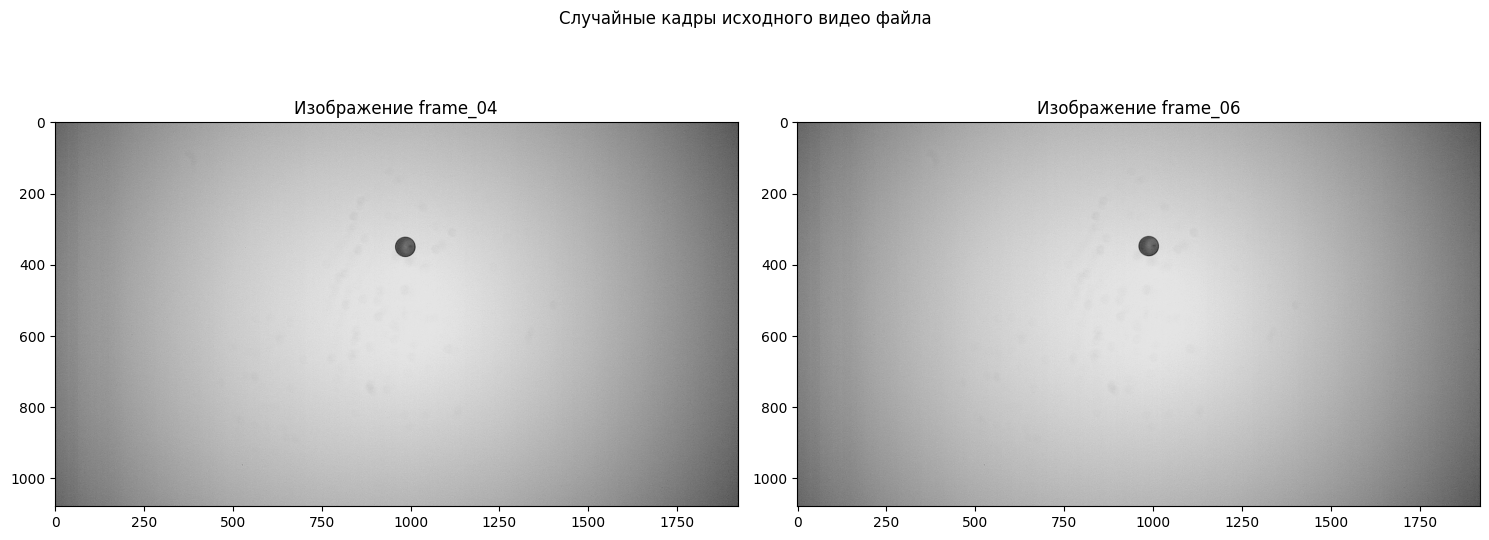

In [5]:
random_img = random.sample(img_names, 2)
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Случайные кадры исходного видео файла")
axs = axs.flatten()
for i, ax in enumerate(axs):
    ax.imshow(cv2.imread(random_img[i]))
    ax.set_title(f'Изображение {Path(random_img[i]).stem}')
plt.tight_layout()
plt.show()

Мы разобрали видео файл на котором отчетливо видна капля, далее попробуем определить ее границы, размер, изменение размера во времени, а так же перемещение в пространстве

## 2. Определения объекта на отдельных изображениях

Для определения положения, площади и характерного размера капли можно использовать разные методы как на основе создани бинарной маски так и непосредственно получая границы с использованием специальных градиентных фильтров типа фильтра Canny. Но в данном уроки используем именно метод на основании сегментации ихображения.

Создадим pipeline обработки изображения для выделения отдельной капли. можно это сделать через библиотеку albumentations или torchvision - transforms. Но у нас простые цели и соответственно методы - будем использовать функцию и методы библиотеки cv

In [6]:
# читаем путь к файлу изображения
img2read = random_img[0]

### Этапы обработки

In [7]:
# 1 читаем файл в черно-белом формате и немного сглаживаем
img =  cv2.imread(img2read, cv2.IMREAD_GRAYSCALE)
blur = cv2.GaussianBlur(img, (9, 9), 0)                 # здесь нет проблем с границами, но все равно можно несколько сгладить 
print(img.shape)                                        # видно что доступен только один канал 

(1080, 1920)


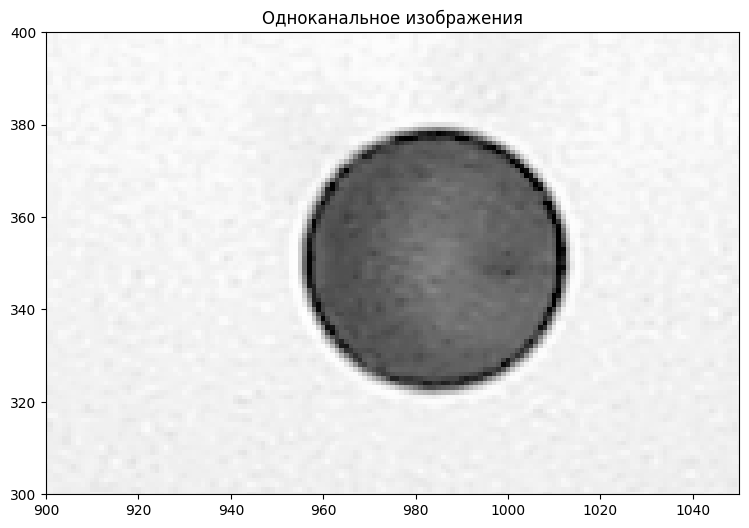

In [8]:
plt.figure(figsize=(10, 6))
plt.title('Одноканальное изображения')
plt.imshow(img, cmap="gray")
plt.xlim([900, 1050])
plt.ylim([300, 400])
plt.show()

Создадим отдельно фон - путем размытия соседних пикселей большим радиусов - для одного изображения это хороший вариант, если есть "пустое" эталонное изображение фона можно использовать его, другой вариант при большом количестве изображений, использовать медианный фон по всем изображениям, если объект перемещает это даст хорошее приближение по фону

In [9]:
# 2 фон (одно изображение)
background = cv2.GaussianBlur(img, (201, 201), 0)

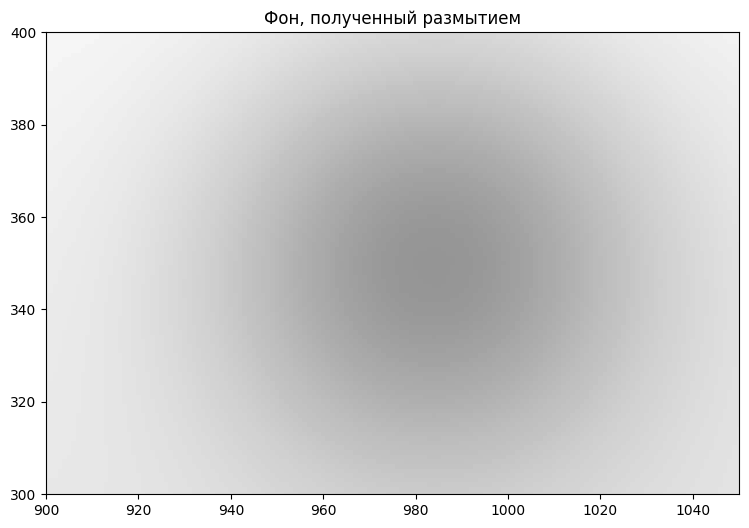

In [10]:
plt.figure(figsize=(10, 6))
plt.title('Фон, полученный размытием')
plt.imshow(background, cmap="gray")
plt.xlim([900, 1050])
plt.ylim([300, 400])
plt.show()

In [11]:
# 3 вычитаем фон из исходного изображения
norm = cv2.subtract(background, blur)

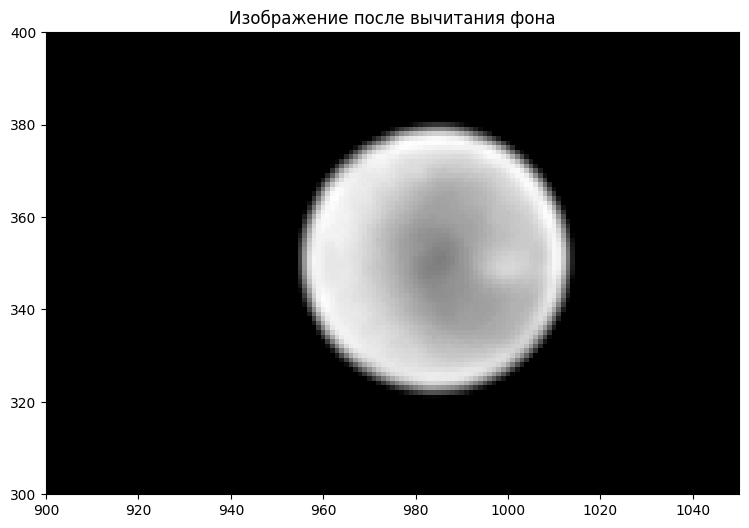

In [12]:
plt.figure(figsize=(10, 6))
plt.title('Изображение после вычитания фона')
plt.imshow(norm, cmap="gray")
plt.xlim([900, 1050])
plt.ylim([300, 400])
plt.show()

In [13]:
# 4 бинаризация  - создаем маску - это изображение (массив пикселей), в котором каждый пиксель принимает одно из двух значений, обычно  0  и  255  - которые являются маркетом наличия объекта
_, mask = cv2.threshold(norm, 20, 255, cv2.THRESH_BINARY)

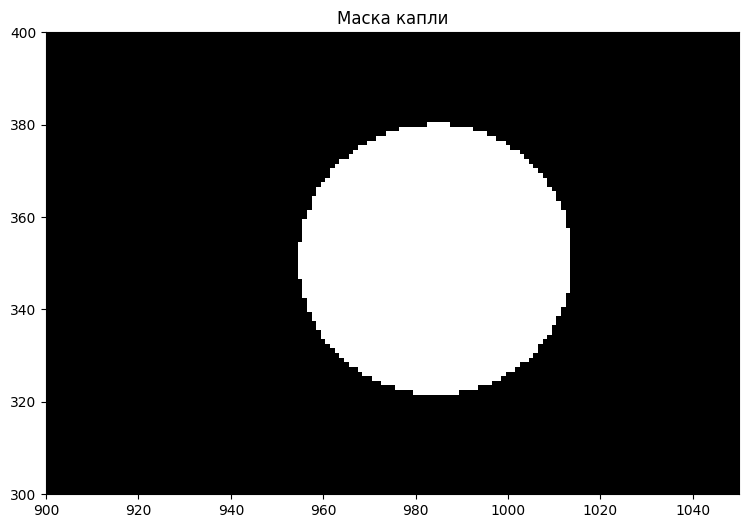

In [14]:
plt.figure(figsize=(10, 6))
plt.title('Маска капли')
plt.imshow(mask, cmap="gray")
plt.xlim([900, 1050])
plt.ylim([300, 400])
plt.show()

Иногда контуры могут быть не гладкими или могут получаться паразитные маски на изображении - это можно убрать с помощью последовательного примения морфологических операций OPEN и CLOSE, которые удаляют мелкий шум, сглаживают границы и делают область капли более цельной

In [15]:
# 5 очистка маски 
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

вообще у нас очень хорошее изображение капли, тут и так все хорошо

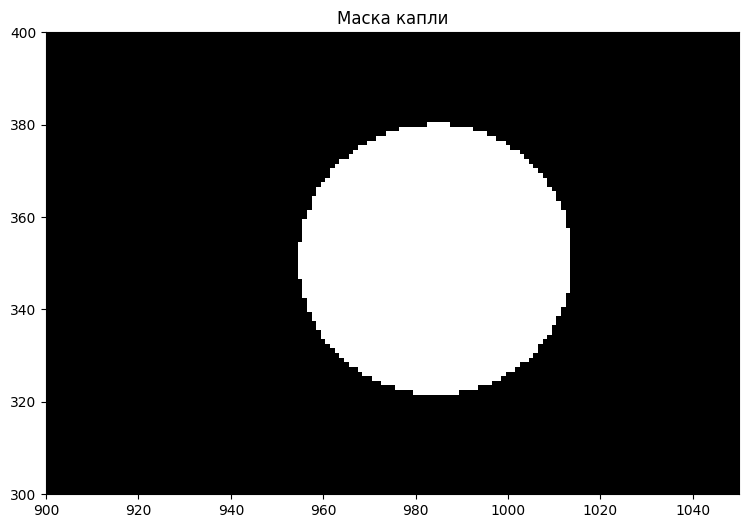

In [16]:
plt.figure(figsize=(10, 6))
plt.title('Маска капли')
plt.imshow(mask, cmap="gray")
plt.xlim([900, 1050])
plt.ylim([300, 400])
plt.show()

Далее необходимо преобразовать-разбить маску на отдельные контуры. Контур — это граница связной области на бинарной маске, представленная набором точек. Он не совпадает с самой маской объекта, а лишь ограничивает область, которую этот объект занимает.

In [17]:
# 5) поиск контуров
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f'Количество найденных контуров на изображении, {len(contours)}')

Количество найденных контуров на изображении, 1


### Основные характеристики контура

После выделения контура его можно описывать с помощью набора геометрических характеристик. В OpenCV контур сам по себе представляет набор точек границы объекта, а его свойства вычисляются отдельными функциями. 

- `cv2.contourArea(cnt)` — площадь области, ограниченной контуром.
- `cv2.arcLength(cnt, True)` — периметр контура.
- `cv2.moments(cnt)` — моменты контура; по ним можно вычислить площадь, центр тяжести и другие интегральные характеристики формы.
- `cx = M["m10"] / M["m00"]`, `cy = M["m01"] / M["m00"]` — координаты центра тяжести, вычисленные по моментам.
- `cv2.approxPolyDP(cnt, epsilon, True)` — аппроксимация контура ломаной с меньшим числом точек.
- `cv2.minAreaRect(cnt)` — минимальный ограничивающий прямоугольник с учетом поворота.
- `cv2.minEnclosingCircle(cnt)` — минимальная описывающая окружность.
- `cv2.fitEllipse(cnt)` — аппроксимация контура эллипсом.
- `cv2.pointPolygonTest(cnt, pt, measureDist)` — проверка, лежит ли точка внутри контура, на нем или вне его.

Для задач анализа капель наиболее полезными обычно являются площадь (`contourArea`), периметр (`arcLength`), центр тяжести через `moments`, а также ограничивающий прямоугольник или описывающая окружность для оценки характерного размера объекта.

Для нашей задачи вполне допустими сразу использовать встроенные инструменты типа **minEnclosingCircle**, но так как капля не всегда будет сферической лучше определить центр области и по площадь контура найти эквивалентный радиус

In [18]:
cnt_geom = []
for obj in contours:
    # площадь контура
    Area = cv2.contourArea(obj)
    # центр тяжести
    M = cv2.moments(obj)
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    r = np.sqrt(Area/np.pi)
    cnt_geom.append([cx, cy, r])

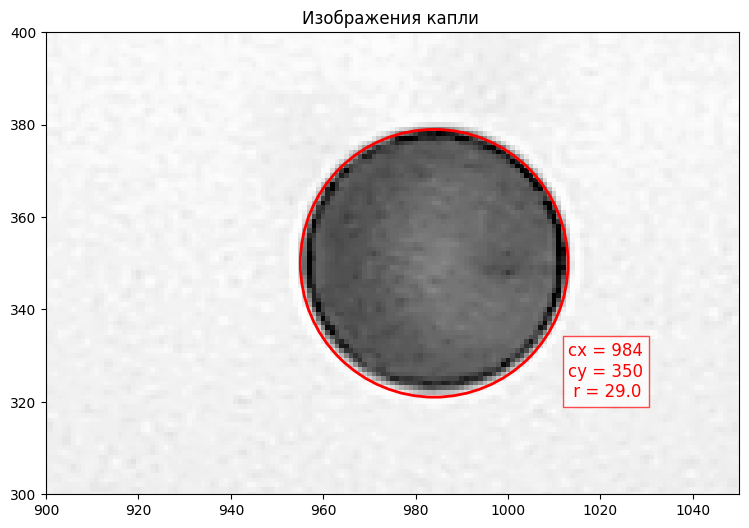

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Изображения капли ')
ax.imshow(img, cmap="gray")
for k in range(len(cnt_geom)):
    cx, cy, r = cnt_geom[k]
    droplet = Circle((cx, cy), r, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(droplet)
    # подпись рядом
    ax.text( cx + r, cy - r, 
            f'cx = {cx}\ncy = {cy}\n r = {r:0.01f}', 
            color='red',   fontsize=12,  
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))
plt.xlim([900, 1050])
plt.ylim([300, 400])
plt.show()

Теперь когда мы показали что все работает можно собрать это все в функцию для обработки всех изображений

In [20]:
def droplet_detection(img_path, blurd= 9, blurb =201, kerd = 5):
    img =  cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    blur = cv2.GaussianBlur(img, (blurd, blurd), 0)                  
    background = cv2.GaussianBlur(img, (blurb, blurb), 0)
    norm = cv2.subtract(background, blur)
    _, mask = cv2.threshold(norm, 20, 255, cv2.THRESH_BINARY)
    kernel = np.ones((kerd, kerd), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt_geom = []
    for obj in contours:
        # площадь контура
        Area = cv2.contourArea(obj)
        # центр тяжести
        M = cv2.moments(obj)
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        r = np.sqrt(Area/np.pi)
        cnt_geom.append([cx, cy, r])
    return img, cnt_geom, mask

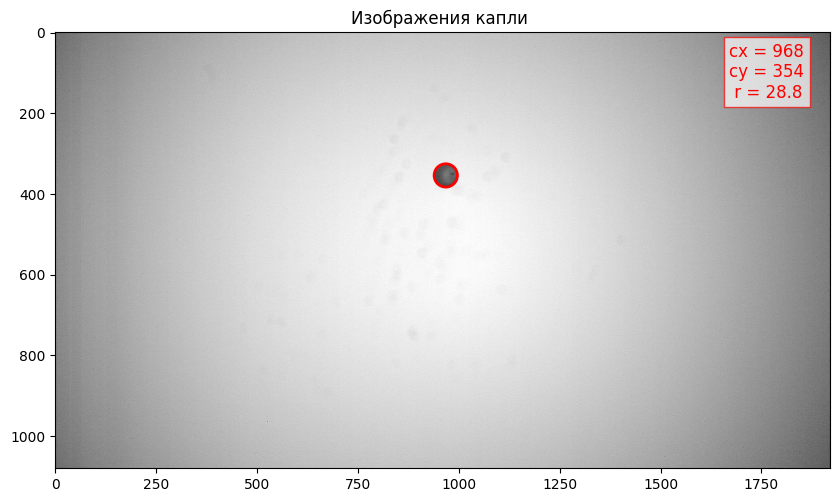

In [21]:
# протестируем функцию
img2plot =  img_names[16]
img, cnt_geom, _ = droplet_detection(img2plot)
# отобразим результаты
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Изображения капли ')
ax.imshow(img, cmap="gray")
for k in range(len(cnt_geom)):
    cx, cy, r = cnt_geom[k]
    droplet = Circle((cx, cy), r, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(droplet)
    # подпись рядом
    ax.text( 0.87*frame_width, 0.15*frame_height,
            f'cx = {cx}\ncy = {cy}\n r = {r:0.01f}', 
            color='red',   fontsize=12,  
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))
plt.show()

Можно построить траекторию движения капли

In [22]:
pc = np.zeros([total_frames,2])
for i, img in enumerate(img_names):
    _, cnt_geom, _ = droplet_detection(img)
    cx, cy, _ = cnt_geom[0]
    pc[i,:]= cx, cy

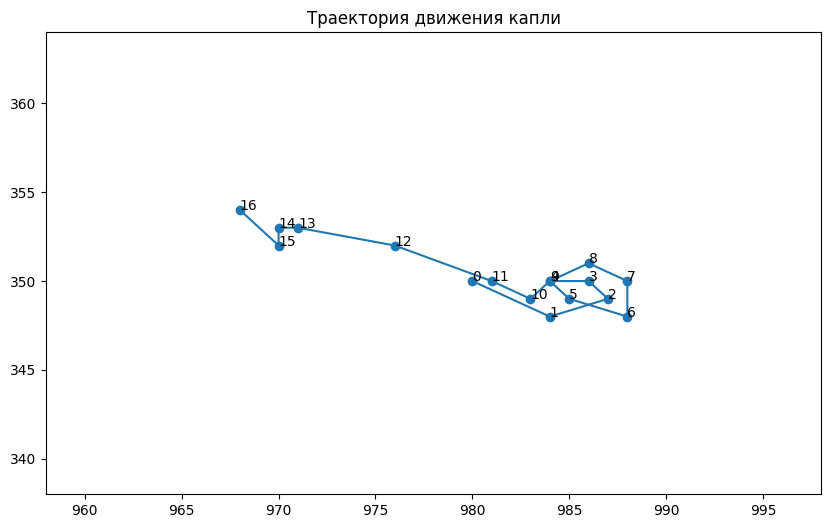

In [23]:
plt.figure(figsize=(10, 6))
plt.title('Траектория движения капли')
plt.plot(pc[:,0], pc[:,1])
plt.scatter(pc[:, 0], pc[:, 1])
for i, (x, y) in enumerate(pc):
    plt.text(x, y, str(i), fontsize=10)
plt.xlim([min(pc[:,0])-10, max(pc[:,0])+10])
plt.ylim([min(pc[:,1])-10, max(pc[:,1])+10])
plt.show()

Перезапишем видео файл с дополнительной информацией на изображении

In [24]:
out_path = path2rez + 'output_video.mp4'
# Инициализируем объект для записи видео с кодеком 'mp4v'.
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(out_path, fourcc, fps, (frame_width, frame_height))
for img2write in img_names:
    frame, cnt_geom, _ = droplet_detection(img2write)
    frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
    for k in range(len(cnt_geom)):
        cx, cy, r = cnt_geom[k]
        cv2.circle(frame ,(cx,cy), int(r), (0,0,255), 2)
        # с текстом муторно
        x_text = int(0.80 * frame_width)
        y_text = int(0.10 * frame_height)
        cv2.putText(frame, f"cx = {cx:.0f}", (x_text, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(frame, f"cy = {cy:.0f}", (x_text, y_text + 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(frame, f"r = {r:.1f}", (x_text, y_text + 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    out.write(frame)

out.release()
print(f"Видео сохранено: {out_path}")

Видео сохранено: artifacts/output_video.mp4


Мы работает в пикселях и кадрах, но когда у нас есть данные камеры и мы знаем масштаб изображения - мы можем перейти в абсолютную систему координат. Эта важная информация которую мы должны иметь до начала проведения экспериментов

In [25]:
img4pap_full_path = 'data\\paper_img.jpg'
img4pap_full =  cv2.imread(img4pap_full_path)
img4pap_full = cv2.cvtColor(img4pap_full, cv2.COLOR_BGR2RGB)

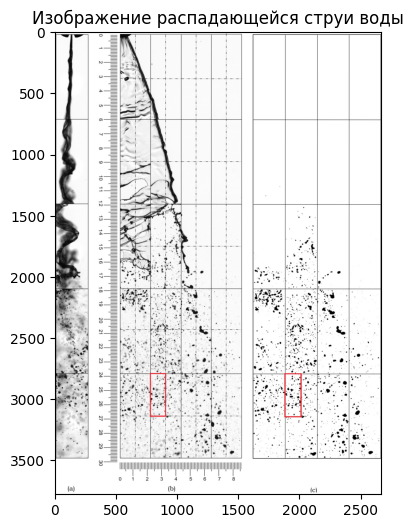

In [26]:
plt.figure(figsize=(10, 6))
plt.title('Изображение распадающейся струи воды')
plt.imshow(img4pap_full)
plt.show()

В статье приведено уже обработанное изображение с наложенной сеткой, давай попробуем обработать только его часть выделенную красным прямоугольником и сравним результат с правой картиной - результатом обработки авторов статьи https://doi.org/10.1016/j.ijmultiphaseflow.2025.105311

In [27]:
# сегмент изображения
img4pap_path = 'data\\org_img.png'
img4pap_cut =  cv2.imread(img4pap_path)
# оригинальная маска
img4pap_mask_path = 'data\\org_mask.png'
img4pap_mask =  cv2.imread(img4pap_mask_path)

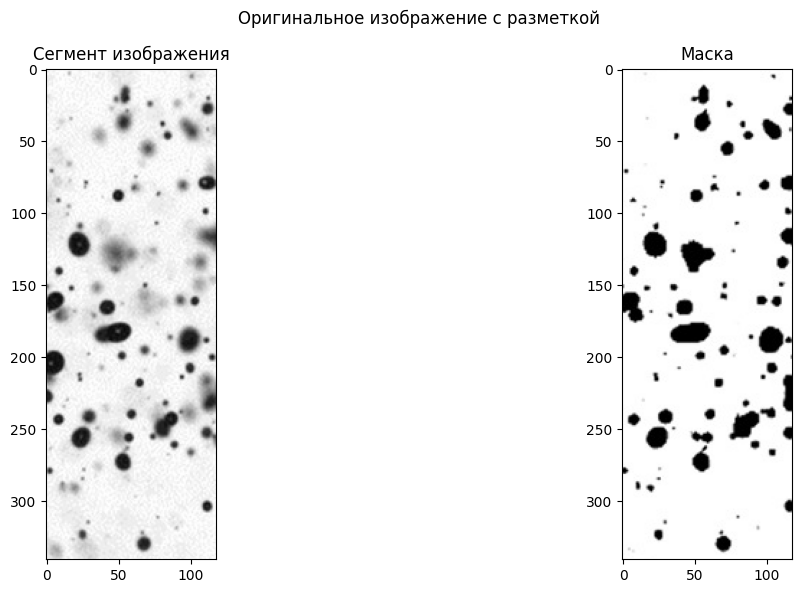

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Оригинальное изображение с разметкой")
axs = axs.flatten()
# исходное изображение
axs[0].imshow(img4pap_cut)
axs[0].set_title(f'Сегмент изображения')
# исходное изображение
axs[1].imshow(img4pap_mask)
axs[1].set_title(f'Маска')
plt.tight_layout()
plt.show()

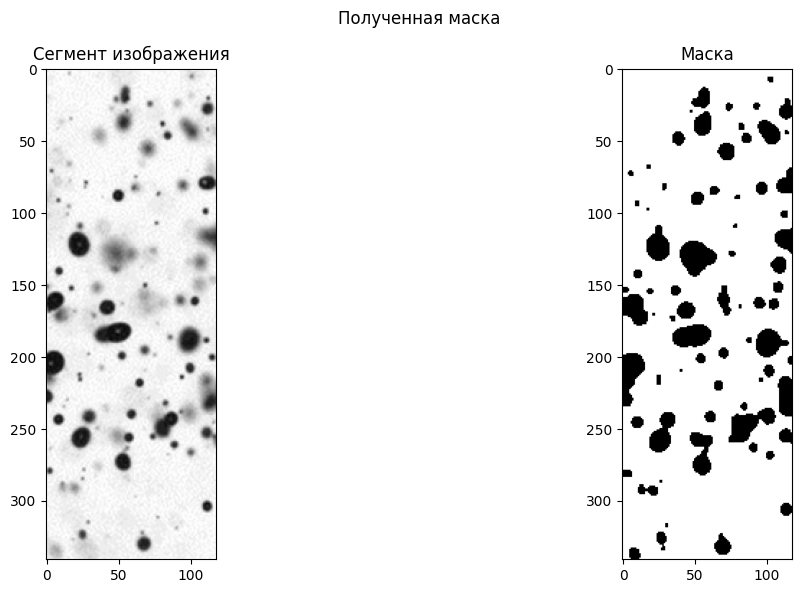

In [29]:
# протестируем функцию
img, cnt_geom, mask = droplet_detection(img4pap_path,  blurd= 3, blurb =501, kerd = 2)      # можно варьировать параметры обработки изображения
# отобразим результаты
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Полученная маска")
axs = axs.flatten()
# исходное изображение
axs[0].imshow(img4pap_cut)
axs[0].set_title(f'Сегмент изображения')
# исходное изображение
axs[1].imshow(~mask, cmap="gray")
axs[1].set_title(f'Маска')
plt.tight_layout()
plt.show()

Сравним полученные маски качественно, потому что для количественного сравнения, нужно считать достаточно специфические параметры как общая площадь, доля перекрытия объектов и другие общие метрики сегментации и классификации. Они применимы как к классическим алгоритмам, так и нейросетевым решениям если есть эталонная разметка. Ну и нужно не просто сравнивать, а предварительно размечать изображение, чтобы сравнение было корректным

| Формула | Пояснение |
|---|---|
| $IOU = \dfrac{|X \cap Y|}{|X \cup Y|}$ | IOU как мера схожести множеств |
| $IOU = \dfrac{TP}{TP + FP + FN}$ | IOU через TP, FP, FN |
| $Precision = \dfrac{TP}{TP + FP}$ | precision — доля верных предсказаний |
| $Recall = \dfrac{TP}{TP + FN}$ | recall — доля найденных объектов |
| $F1 = \dfrac{2|X \cap Y|}{|X| + |Y|}$ | F1 как мера схожести множеств |
| $F1 = \dfrac{2}{\frac{1}{Precision} + \frac{1}{Recall}}$ | F1 как среднее гармоническое precision и recall |
| $F1 = \dfrac{2TP}{2TP + FP + FN}$ | F1 через FP, FP, FN |

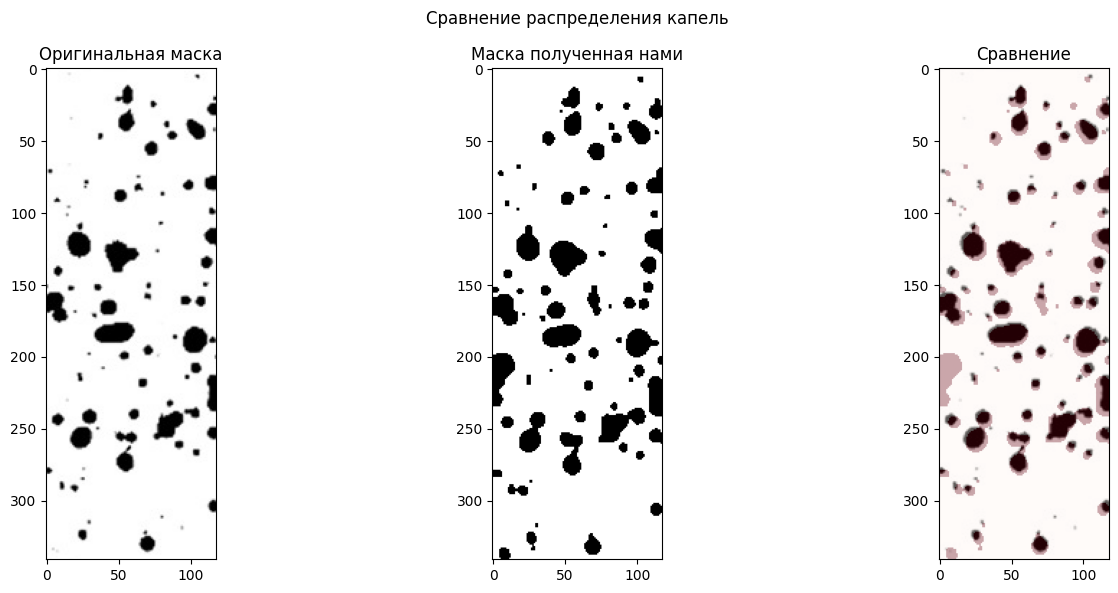

In [30]:
# отобразим результаты
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("Сравнение распределения капель")
axs = axs.flatten()
# оригинальная маска
axs[0].imshow(img4pap_mask, cmap="gray")
axs[0].set_title(f'Оригинальная маска')
# наша маска
axs[1].imshow(~mask, cmap="gray")
axs[1].set_title(f'Маска полученная нами')
# наложение полученных масок изображения
axs[2].imshow(img4pap_mask, cmap="gray")
axs[2].imshow(mask, cmap="Reds", alpha=0.35)
axs[2].set_title(f'Сравнение')
plt.tight_layout()
plt.show()

Несколько замечаний:
 - изображение маски оказалось немного сдвинуто - но это проблема связана скорее с моей постобработной изображения из статьи (та как у нас есть только оттуда данные);
 - конечно нужно настраивать параметры обработки под эталонное размеченное изображение и ориентироваться на метрику IOU;
 - вполне возможно использовать Canny фильтры, но фактически Canny выделяет области с большим градиентом яркости/интенсивности и иногда получается несвязные области или перекрывающиемся.

In [31]:
# Пример с фильтром Canny
t_lower = 50  
t_upper = 150 
edge = cv2.Canny(img, t_lower, t_upper)

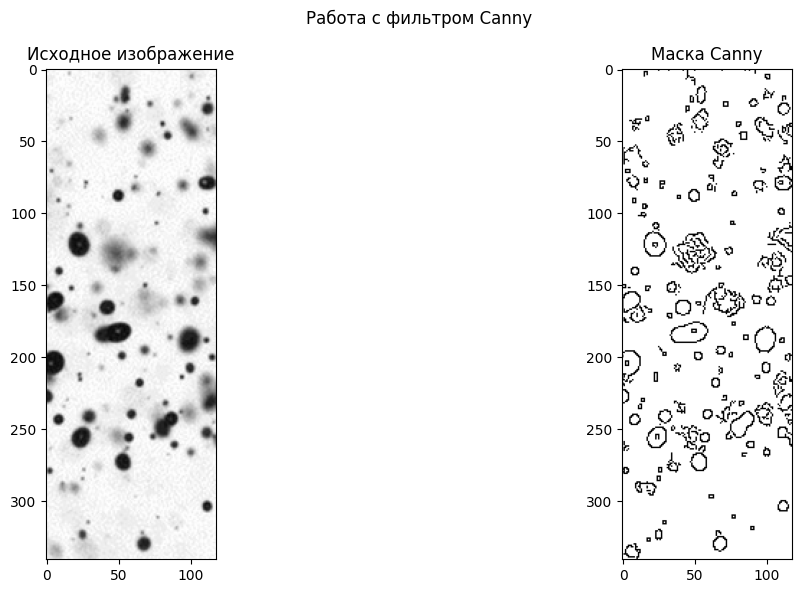

In [40]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Работа с фильтром Canny")
axs = axs.flatten()
# исходное изображение
axs[0].imshow(img4pap_cut, cmap="gray")
axs[0].set_title(f'Исходное изображение')
# исходное изображение
axs[1].imshow(~edge, cmap="gray")
axs[1].set_title(f'Маска Canny')
plt.tight_layout()
plt.show()

## 3. Использование предобученных нейросетей

Вообще для задач сегментации хорошо работает связка YOLO(детекция объекта) + SAM (сегментация изображения в полученных bbox). Однако YOLO по умолчанию не содержит объектов типа "капля" или что то похожего. Здесь можно обойтись просто сегментацией, без выделения классов объектов. Это более тяжелая работа так как обрабатывается изображение целиком, ну и найденные сегментированные объекты могут быть не каплями а иными неоднородностями  и требовать дополнительной проверки.

Работу с нейросетевыми моделями лучше выполнять на графической процессоре........

In [33]:
from ultralytics import YOLO, SAM 

C:\Users\int\.conda\envs\mmsegm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
# выберем в качестве устройства gpu, если не получится вернемся на cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

Используем модель семества SAM от Meta        https://docs.ultralytics.com/models/sam/#sam-prediction-example

In [35]:
sam = SAM("sam_b.pt")      # mask
# Display model information (optional)
sam.info()

Model summary: 238 layers, 93735472 parameters, 93735472 gradients


(238, 93735472, 93735472, 0)

Возьмем все тоже исходное изображение с распадом струи воды

In [45]:
# Run inference
results = sam(img4pap_cut, device=device)
result = results[0]
masks = result.masks[1:].data.cpu().numpy() > 0.75                # threshold - '
print("Количество масок:", len(masks))


0: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 1 49, 1 50, 1 51, 1 52, 1 53, 1 54, 1 55, 1 56, 1 57, 1 58, 1 59, 1 60, 7329.4ms
Speed: 8.7ms preprocess, 7329.4ms inference, 0.0ms postprocess per image at shape (1, 3, 1024, 1024)


Количество масок: 60


Здесь создаются отдельные маски для всех объектов

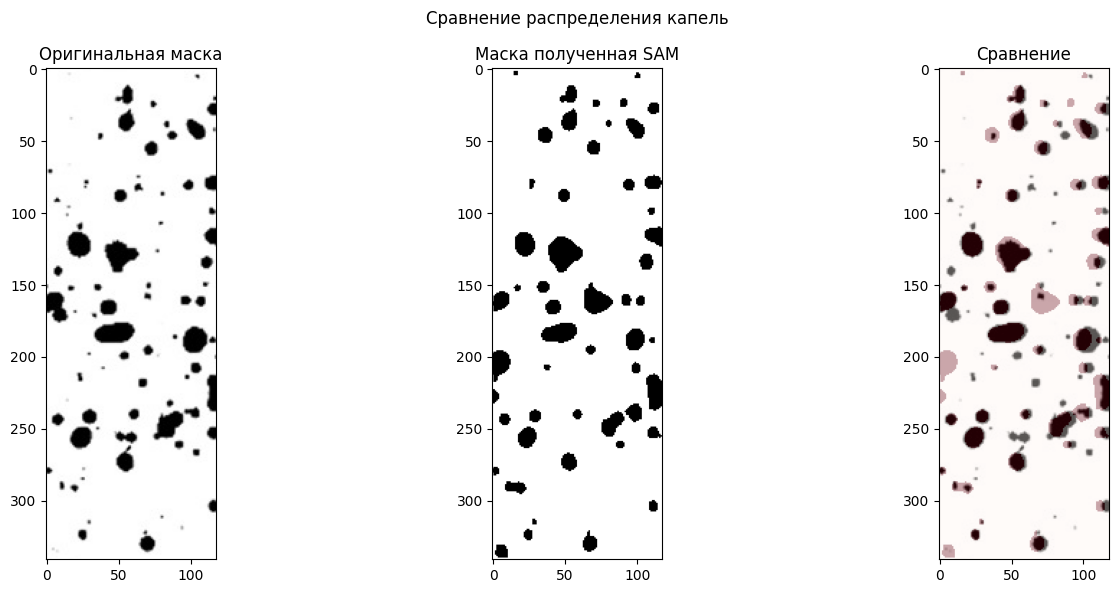

In [46]:
# отобразим результаты
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("Сравнение распределения капель")
axs = axs.flatten()
# оригинальная маска
axs[0].imshow(img4pap_mask, cmap="gray")
axs[0].set_title(f'Оригинальная маска')
# наша маска
combined_mask = np.any(masks, axis=0)
axs[1].imshow(~combined_mask, cmap="gray")
axs[1].set_title(f'Маска полученная SAM')
# наложение полученных масок изображения
axs[2].imshow(img4pap_mask, cmap="gray")
axs[2].imshow(combined_mask, cmap="Reds", alpha=0.35)
axs[2].set_title(f'Сравнение')
plt.tight_layout()
plt.show()

Здесь так же можно поиграть параметрами

## Выводы

1. Видео можно разложить на отдельные кадры, обработать каждый кадр независимо и затем собрать результаты обратно;
2. Для изображений с достаточно стабильным фоном и хорошим контрастом капли простой классический pipeline работает надежно: перевод в оттенки серого, мягкое сглаживание, оценка фона, вычитание фона, бинаризация, морфологическая очистка маски и поиск контуров;
3. Контур позволяет вычислять основные геометрические характеристики объекта: площадь, центр тяжести, периметр и характерный размер;
4. Эквивалентный радиус, вычисленный по площади контура, удобен как простая сводная характеристика размера, но он не описывает вытянутую или сильно деформированную каплю полностью. Хотя бы знаем, что нет ничего лучше Заутеровского диаметра;
5. Для перехода от пикселей и кадров к физическим единицам необходимы масштаб изображения и частота кадров камеры;
6. Качество сегментации заметно зависит от параметров порога, размера фильтра и морфологических операций, поэтому их желательно подбирать по данным и проверять по эталонной разметке;
7. Для количественной оценки масок полезно использовать метрики IoU, Dice/F1, precision и recall. Эти метрики важны не только для нейронных сетей, но и для любого метода сегментации.
8. Фильтр Canny выделяет в первую очередь границы (градиенты яркости), поэтому для оценки площади и центра области капли бинарная сегментация обычно удобнее;
9. Модели типа SAM могут упростить сегментацию сложных сцен, но они тяжелее вычислительно и требуют дополнительной проверки того, что выделенный объект действительно соответствует капле;
10. Для отслеживания нескольких капель на видео одной покадровой сегментации недостаточно: дополнительно нужен этап сопоставления объектов между соседними кадрами.
